# 06B - ResNet50 Fine-Tuning in WSL2/GPU

This notebook fine-tunes the already-trained ResNet50 model from `06_resnet50.ipynb`.

It does not retrain the classifier head from scratch. It loads:

`models/experiments/resnet50_aug_oversampled.keras`

Then it unfreezes a small number of top ResNet50 layers and trains with a very low learning rate.

Current result before fine-tuning:

- `resnet50_aug_oversampled`
- accuracy about 0.9699
- macro F1 about 0.9534

Current best comparison point:

- `efficientnetb0_aug_oversampled`
- accuracy about 0.9724
- macro F1 about 0.9565

Keep the fine-tuned ResNet50 only if it improves macro F1 or weak-class metrics without hurting general performance.


## 1. Project setup


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system


## 2. Imports and configuration


In [2]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    GROUPED_SPLITS_DIR,
)

# Use grouped source-image splits to avoid offline-augmentation leakage.
SPLITS_DIR = GROUPED_SPLITS_DIR
from src.data.dataloaders import make_dataset_from_dataframe
from src.data.prepare_dataset import targeted_oversample_dataframe
from src.models.resnet50_model import ResNet50Preprocess, unfreeze_resnet50_top
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

SOURCE_EXPERIMENT_NAME = "resnet50_aug_oversampled"
EXPERIMENT_NAME = "resnet50_aug_oversampled_finetuned_wsl"
TARGET_MIN_COUNT = 500

FINE_TUNE_EPOCHS = 3
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_LAYERS = 30

EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
SOURCE_MODEL_PATH = EXPERIMENT_MODELS_DIR / f"{SOURCE_EXPERIMENT_NAME}.keras"

EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Source model:", SOURCE_MODEL_PATH)
print("Experiment:", EXPERIMENT_NAME)
print("Fine-tune layers:", FINE_TUNE_LAYERS)
print("Fine-tune learning rate:", FINE_TUNE_LEARNING_RATE)


I0000 00:00:1777454490.386675   28908 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777454490.432498   28908 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777454513.336610   28908 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Source model: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/resnet50_aug_oversampled.keras
Experiment: resnet50_aug_oversampled_finetuned_wsl
Fine-tune layers: 30
Fine-tune learning rate: 1e-05


## 3. Load split files and class names

If split CSV files contain Windows paths such as `D:\\...`, the dataloader converts them to `/mnt/d/...` automatically when running under WSL.


In [3]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH, SOURCE_MODEL_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Original train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Original train/val/test: 19674 4788 4815
Classes: 28


## 4. Recreate oversampled training dataframe

This matches the frozen ResNet50 experiment so fine-tuning uses the same training distribution.


In [4]:
original_counts = train_df["class_name"].value_counts().reindex(class_names)
train_oversampled_df = targeted_oversample_dataframe(
    train_df,
    target_min_count=TARGET_MIN_COUNT,
    class_column="class_name",
    random_state=RANDOM_SEED,
)

oversampled_counts = train_oversampled_df["class_name"].value_counts().reindex(class_names)
oversampling_summary = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": original_counts.values,
    "oversampled_train_count": oversampled_counts.values,
})
oversampling_summary["added_rows"] = (
    oversampling_summary["oversampled_train_count"]
    - oversampling_summary["original_train_count"]
)
oversampling_summary["oversampled_ratio"] = (
    oversampling_summary["oversampled_train_count"]
    / oversampling_summary["original_train_count"]
).round(2)

display(oversampling_summary.sort_values("added_rows", ascending=False))
print("Original train rows:", len(train_df))
print("Oversampled train rows:", len(train_oversampled_df))


,class_name,original_train_count,oversampled_train_count,added_rows,oversampled_ratio
21,Pomegranate__Rotten,131,500,369,3.82
14,Jujube__Healthy,132,500,368,3.79
11,Grape__Rotten,134,500,366,3.73
15,Jujube__Rotten,134,500,366,3.73
12,Guava__Healthy,134,500,366,3.73
10,Grape__Healthy,135,500,365,3.70
13,Guava__Rotten,135,500,365,3.70
20,Pomegranate__Healthy,137,500,363,3.65
7,Carrot__Rotten,390,500,110,1.28
5,Bellpepper__Rotten,390,500,110,1.28


Original train rows: 19674
Oversampled train rows: 23590


## 5. Build TensorFlow datasets


In [5]:
train_ds = make_dataset_from_dataframe(train_oversampled_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


I0000 00:00:1777454540.813874   28908 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 6. Load saved ResNet50 model and unfreeze top layers

`ResNet50Preprocess` is imported before `load_model()` so Keras can deserialize the custom preprocessing layer saved inside the model.


In [6]:
custom_objects = {"ResNet50Preprocess": ResNet50Preprocess}
model = tf.keras.models.load_model(SOURCE_MODEL_PATH, custom_objects=custom_objects, compile=False)
model = unfreeze_resnet50_top(model, trainable_layers=FINE_TUNE_LAYERS)
model = compile_model(model, learning_rate=FINE_TUNE_LEARNING_RATE)
model.summary()

resnet_base = next(
    layer for layer in model.layers
    if isinstance(layer, tf.keras.Model) and layer.name.startswith("resnet50")
)
trainable_base_layers = sum(1 for layer in resnet_base.layers if layer.trainable)
trainable_weights = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)

print("Trainable ResNet50 base layers:", trainable_base_layers)
print("Trainable weights:", trainable_weights)


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocess             │ (None, 224, 224, 3)    │             0 │
│ (ResNet50Preprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 28)             │        57,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,645,084 (90.20 MB)

 Trainable params: 14,486,044 (55.26 MB)

 Non-trainable params: 9,159,040 (34.94 MB)

Trainable ResNet50 base layers: 21
Trainable weights: 14486044


## 7. Fine-tune


In [7]:
fine_tune_checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_best.keras"

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=FINE_TUNE_EPOCHS,
    checkpoint_path=fine_tune_checkpoint_path,
)


Epoch 1/3


I0000 00:00:1777454559.431518   29367 cuda_dnn.cc:461] Loaded cuDNN version 92100


384/738 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.9743 - loss: 0.0666

W0000 00:00:1777454632.085580   29493 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


672/738 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9773 - loss: 0.0610

...

738/738 ━━━━━━━━━━━━━━━━━━━━ 135s 180ms/step - accuracy: 0.9908 - loss: 0.0296 - val_accuracy: 0.9766 - val_loss: 0.0907 - learning_rate: 1.0000e-05
Epoch 3/3
384/738 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - accuracy: 0.9934 - loss: 0.0230

W0000 00:00:1777454906.346641   30766 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


672/738 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9933 - loss: 0.0221

W0000 00:00:1777454950.093349   30753 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


738/738 ━━━━━━━━━━━━━━━━━━━━ 133s 177ms/step - accuracy: 0.9935 - loss: 0.0204 - val_accuracy: 0.9766 - val_loss: 0.0940 - learning_rate: 1.0000e-05


## 8. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.983128,0.049559,0.975146,0.088729,0.00001
1,0.990844,0.029607,0.976608,0.090705,0.00001
2,0.993472,0.020418,0.976608,0.093973,0.00001


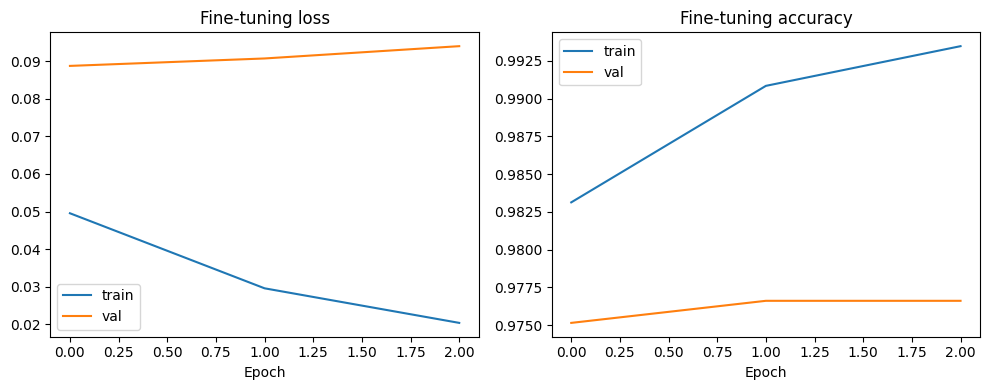

In [8]:
history_df = pd.DataFrame(history.history)
display(history_df)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train")
plt.plot(history_df["val_loss"], label="val")
plt.title("Fine-tuning loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train")
plt.plot(history_df["val_accuracy"], label="val")
plt.title("Fine-tuning accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 9. Evaluate on test set


In [9]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


W0000 00:00:1777454999.758732   31301 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


,precision,recall,f1-score,support
Apple__Healthy,0.945813,0.974619,0.960000,394.000000
Apple__Rotten,0.972340,0.942268,0.957068,485.000000
Banana__Healthy,1.000000,0.993031,0.996503,287.000000
Banana__Rotten,0.993814,0.997930,0.995868,483.000000
Bellpepper__Healthy,0.980000,0.960784,0.970297,102.000000
Bellpepper__Rotten,0.880000,0.880000,0.880000,100.000000
Carrot__Healthy,0.952830,0.980583,0.966507,103.000000
Carrot__Rotten,0.955556,0.905263,0.929730,95.000000
Cucumber__Healthy,0.952381,0.980392,0.966184,102.000000
Cucumber__Rotten,0.946237,0.916667,0.931217,96.000000


Test accuracy: 0.9715
Macro F1: 0.965
Weighted F1: 0.9715


## 10. Compare with previous model reports


In [10]:
comparison_paths = {
    "plain_baseline": FIGURES_DIR / "baseline_cnn_classification_report.csv",
    "baseline_aug_oversampled": FIGURES_DIR / "baseline_cnn_aug_oversampled_classification_report.csv",
    "mobilenetv2_finetuned_wsl": FIGURES_DIR / "mobilenetv2_aug_oversampled_finetuned_wsl_classification_report.csv",
    "efficientnetb0_frozen": FIGURES_DIR / "efficientnetb0_aug_oversampled_classification_report.csv",
    "efficientnetb0_finetuned_wsl": FIGURES_DIR / "efficientnetb0_aug_oversampled_finetuned_wsl_classification_report.csv",
    "resnet50_frozen": FIGURES_DIR / "resnet50_aug_oversampled_classification_report.csv",
}

rows = []
for name, path in comparison_paths.items():
    if path.exists():
        prev = pd.read_csv(path, index_col=0)
        rows.append({
            "experiment": name,
            "accuracy": float(prev.loc["accuracy", "precision"]),
            "macro_f1": float(prev.loc["macro avg", "f1-score"]),
            "weighted_f1": float(prev.loc["weighted avg", "f1-score"]),
        })

rows.append({
    "experiment": EXPERIMENT_NAME,
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
})

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,experiment,accuracy,macro_f1,weighted_f1
0,plain_baseline,0.755464,0.700839,0.744463
1,baseline_aug_oversampled,0.756148,0.721686,0.756913
2,mobilenetv2_finetuned_wsl,0.960383,0.936830,0.960243
3,efficientnetb0_frozen,0.966563,0.953234,0.966393
4,efficientnetb0_finetuned_wsl,0.971963,0.961298,0.971855
5,resnet50_frozen,0.969470,0.961500,0.969377
6,resnet50_aug_oversampled_finetuned_wsl,0.971547,0.964980,0.971523


## 11. Weak class check


In [11]:
weak_classes = [
    "Tomato__Rotten",
    "Bellpepper__Rotten",
    "Potato__Rotten",
    "Pomegranate__Rotten",
    "Carrot__Rotten",
    "Guava__Rotten",
    "Jujube__Rotten",
]

available_weak_classes = [name for name in weak_classes if name in report_df.index]
display(report_df.loc[available_weak_classes, ["precision", "recall", "f1-score", "support"]])


,precision,recall,f1-score,support
Tomato__Rotten,0.966292,0.895833,0.929730,96.0
Bellpepper__Rotten,0.880000,0.880000,0.880000,100.0
Potato__Rotten,0.854369,0.907216,0.880000,97.0
Pomegranate__Rotten,0.944444,0.971429,0.957746,35.0
Carrot__Rotten,0.955556,0.905263,0.929730,95.0
Guava__Rotten,0.969697,1.000000,0.984615,32.0
Jujube__Rotten,1.000000,0.967742,0.983607,31.0


## 12. Confusion matrix


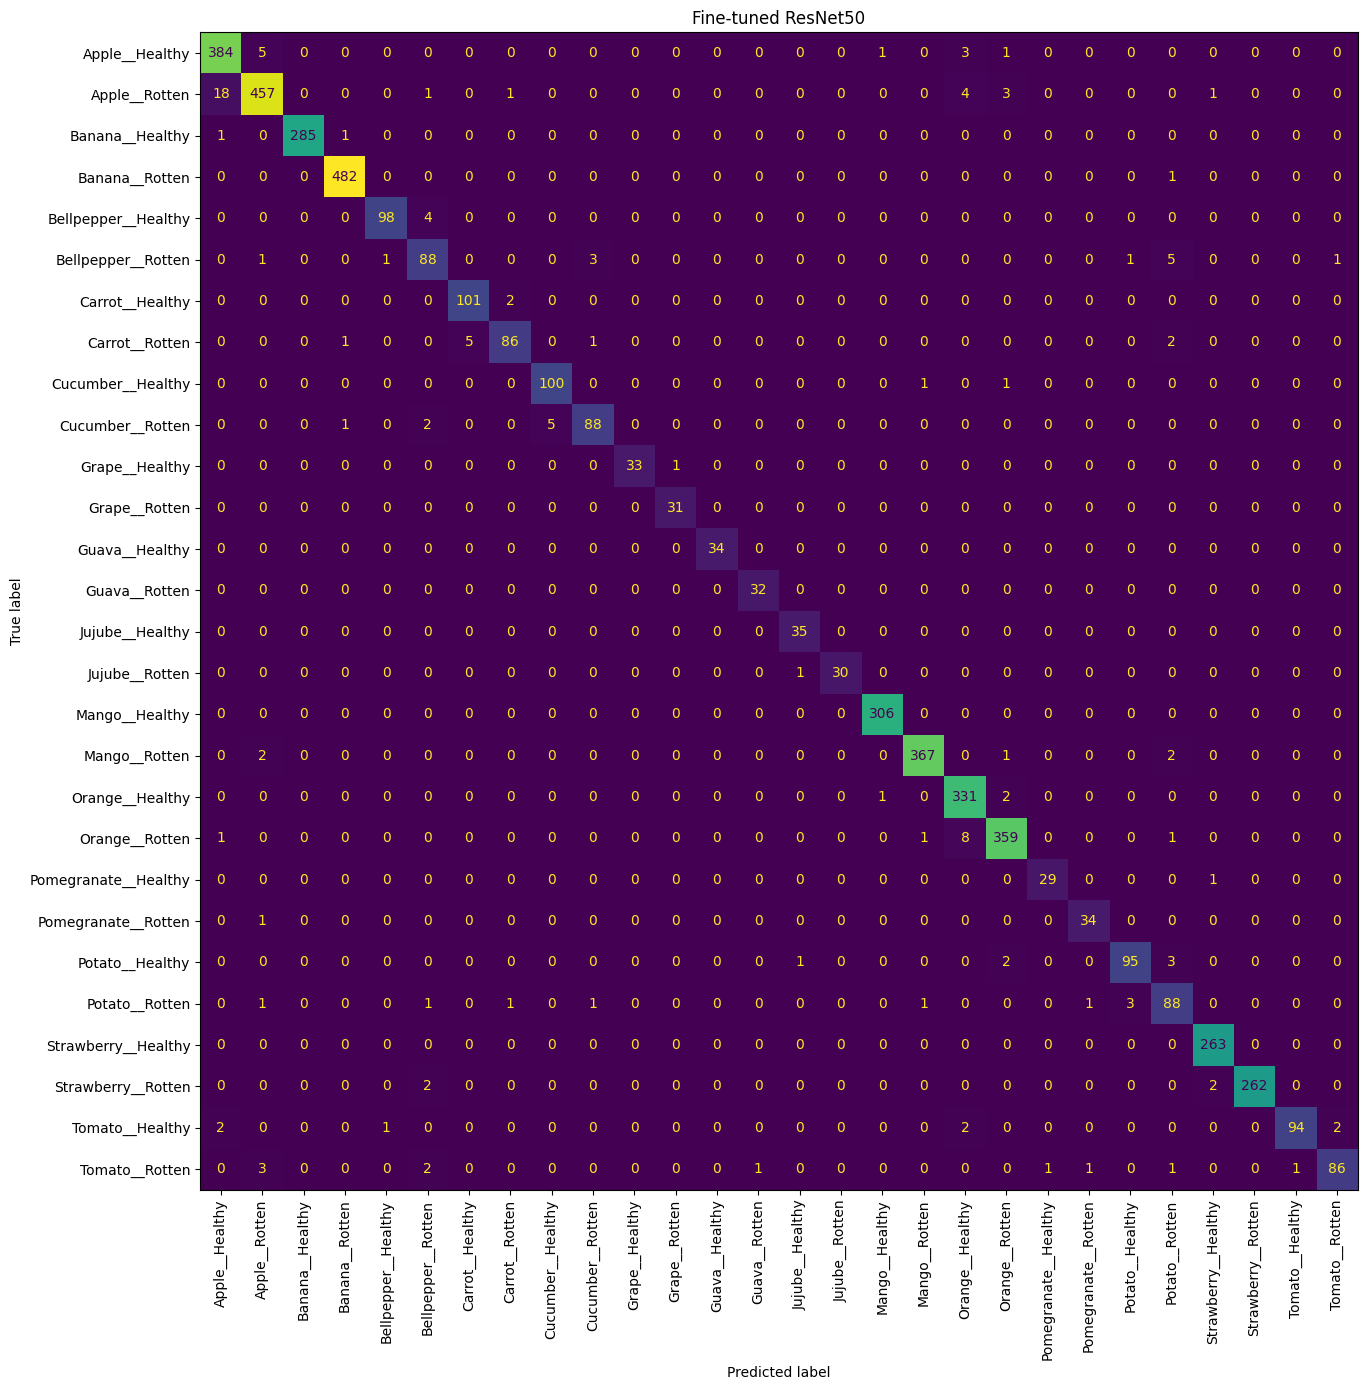

In [12]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Fine-tuned ResNet50")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 13. Save fine-tuned artifacts

This notebook does not overwrite the frozen ResNet50 model or `models/best_model.keras`. Keep the fine-tuned model only if it improves macro F1 and does not hurt weak classes.


In [13]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"
oversampling_summary_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_oversampling_summary.csv"

model.save(model_path)
report_df.to_csv(report_path)
oversampling_summary.to_csv(oversampling_summary_path, index=False)
history_df.to_csv(FIGURES_DIR / f"{EXPERIMENT_NAME}_history.csv", index=False)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "source_model": str(SOURCE_MODEL_PATH),
    "base_model_family": "ResNet50",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "fine_tune_epochs_requested": FINE_TUNE_EPOCHS,
    "fine_tune_learning_rate": FINE_TUNE_LEARNING_RATE,
    "fine_tune_layers": FINE_TUNE_LAYERS,
    "augmentation": True,
    "class_weighting": None,
    "oversampling": {
        "enabled": True,
        "strategy": "targeted_min_count_with_replacement",
        "target_min_count": TARGET_MIN_COUNT,
        "original_train_rows": int(len(train_df)),
        "oversampled_train_rows": int(len(train_oversampled_df)),
    },
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
    "artifacts": {
        "model": str(model_path),
        "checkpoint": str(fine_tune_checkpoint_path),
        "metadata": str(metadata_path),
        "classification_report": str(report_path),
        "oversampling_summary": str(oversampling_summary_path),
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved fine-tuned model:", model_path)
print("Saved metadata:", metadata_path)
print("Did not overwrite frozen ResNet50 or models/best_model.keras")


Saved fine-tuned model: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/resnet50_aug_oversampled_finetuned_wsl.keras
Saved metadata: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/resnet50_aug_oversampled_finetuned_wsl_metadata.json
Did not overwrite frozen ResNet50 or models/best_model.keras


## 14. Decision rule

Keep this fine-tuned model only if it improves over frozen ResNet50 and is competitive with EfficientNetB0:

- frozen ResNet50 accuracy: about 0.9699
- frozen ResNet50 macro F1: about 0.9534
- frozen EfficientNetB0 accuracy: about 0.9724
- frozen EfficientNetB0 macro F1: about 0.9565

If fine-tuning gives only tiny gains or hurts weak classes, keep EfficientNetB0 as the selected candidate and use ResNet50 as comparison evidence in the report.
